In [1]:
# Automatically locate the project's root directory
from crispdm.common.path_service_common import find_project_root

# Data manipulation and analysis using DataFrames
import pandas as pd

# Statistical data visualization built on top of matplotlib
import seaborn as sns

# Parsing and handling JSON data structures
import json

# Creating static, animated, and interactive visualizations
import matplotlib.pyplot as plt

# Numerical computing and support for large, multi-dimensional arrays
import numpy as np

# Fitting and working with statistical distributions (Normal, Skew-Normal, Gamma)
from scipy.stats import norm, skewnorm, gamma

# Object-oriented file system paths management
import pathlib

from IPython.display import display

# Reading and writing YAML configuration files
import yaml

In [2]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "20260521_095921" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "clustering" / "ms_sec_inc_pre" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase3_data_preparation"

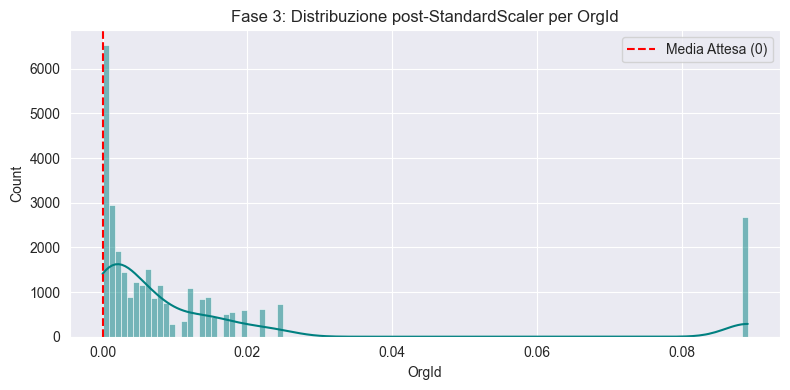

RELAZIONE FASE 3: PREPARAZIONE E TRASFORMAZIONE
Dimensioni del Dataset di Training Finale: (30000, 21)

Verifica Standardizzazione (Z-Score):
 - OrgId: Media = 0.0138 (Attesa ~0), Std = 0.0245 (Attesa ~1)
 - DetectorId: Media = 0.0412 (Attesa ~0), Std = 0.0474 (Attesa ~1)
 - Category: Media = 0.2598 (Attesa ~0), Std = 0.1802 (Attesa ~1)
 - EntityType: Media = 0.1349 (Attesa ~0), Std = 0.0758 (Attesa ~1)
 - EvidenceRole: Media = 0.5054 (Attesa ~0), Std = 0.0505 (Attesa ~1)

Conclusione: Lo spazio delle feature è stato normalizzato correttamente. Il calcolo delle distanze per il clustering non sarà dominato da scale di grandezza diverse.


In [3]:
# =============================================================================
# DEFINIZIONE PERCORSO FASE
# =============================================================================


# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
path_train_prepared = base_phase_path / "3.5.data_formatting.a_train_prepared.parquet"
path_scaling_stats = base_phase_path / "3.3.numeric_scaling.standard_scaling.statistics.json"

df_prepared = pd.read_parquet(path_train_prepared)

with open(path_scaling_stats, 'r', encoding='utf-8') as f:
    scaling_stats = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Selezioniamo le feature numeriche scalate per verificare media ~ 0 e varianza ~ 1
numeric_features = df_prepared.select_dtypes(include=[np.number]).columns
validation_metrics = {}

for col in numeric_features[:5]: # Controlliamo le prime 5 feature per brevità
    validation_metrics[col] = {
        "mean": df_prepared[col].mean(),
        "std": df_prepared[col].std()
    }

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Verifichiamo visivamente l'effetto dello scaling (Distribuzione Gaussiana)
feature_to_plot = numeric_features[0]

plt.figure(figsize=(8, 4))
sns.histplot(df_prepared[feature_to_plot], kde=True, color="teal")
plt.title(f"Fase 3: Distribuzione post-StandardScaler per {feature_to_plot}")
plt.axvline(0, color='red', linestyle='--', label="Media Attesa (0)")
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
print("=========================================================================")
print("RELAZIONE FASE 3: PREPARAZIONE E TRASFORMAZIONE")
print("=========================================================================")
print(f"Dimensioni del Dataset di Training Finale: {df_prepared.shape}")
print("\nVerifica Standardizzazione (Z-Score):")
for col, metrics in validation_metrics.items():
    print(f" - {col}: Media = {metrics['mean']:.4f} (Attesa ~0), Std = {metrics['std']:.4f} (Attesa ~1)")
print("\nConclusione: Lo spazio delle feature è stato normalizzato correttamente. Il calcolo delle distanze per il clustering non sarà dominato da scale di grandezza diverse.")
print("=========================================================================")